In [2]:
import numpy as np
import matplotlib.pyplot as plt
import time
from numba import jit, njit, vectorize, guvectorize

# Numba

**Numba** is a *just-in-time* (JIT) compiler that translates Python functions into optimized machine code at runtime.

When a Python function is decorated with Numba, it is compiled into efficient machine code the first time it is invoked. This often results in performance improvements ranging from 2x to 100x compared to pure Python execution. Numba is especially effective for numerical computations and algorithms that are computationally intensive when implemented in standard Python.

**Key benefits of Numba:**
- Near-C execution speeds while retaining Python syntax and readability  
- Optional automatic parallelization for multi-core CPUs  
- Minimal code modifications required - often just the addition of a decorator

In this notebook, we will explore basic examples of using Numba to optimize Python functions.

## @jit Decorator

### The Basics

The `@numba.jit` decorator enables just-in-time (JIT) compilation of Python functions, potentially yielding significant performance improvements over pure Python execution.

Numba achieves its best performance improvements when working with:
- **NumPy arrays**: Numba excels at optimizing operations on NumPy arrays  
- **Numerical computations**: Loops and mathematical operations are heavily optimized  
- **Type-stable code**: Functions where variable types remain consistent during execution

When a decorated function is called, Numba performs *type inference* - automatically determining the types of all variables in the function. Based on these inferred types, it generates optimized machine code specifically for those types.

Let's start with a simple example to demonstrate Numba's capabilities: computing the sum of all elements in a NumPy array. This example will show the basic usage of the `@jit` decorator and its performance impact.


In [3]:
# Compute the sum of all elements in an array using Numba
@jit
def simple_sum(data):
    s = 0
    for d in data:  # The explicit loop will be optimized by Numba
        s += d
    return s

Adding the decorator to the function instructs Numba to compile it into machine code *the first time the function is called*.

Once compiled, Numba maintains:
- The compiled "jitted" version for optimized execution  
- The original Python implementation, accessible via `simple_sum.py_func()`

This allows us to:
1. Compare performance between compiled and interpreted versions  
2. Access the original Python code for debugging  
3. Verify the correctness of the compilation by comparing results

In [4]:
# Define an arbitrary vector to test the `simple_sum` function
import numpy as np

input_data = 10 * np.random.random(100_000)
input_data[:10]

array([6.3815061 , 4.05141044, 7.53059397, 5.95645073, 5.94109567,
       0.65480907, 5.58456491, 2.7744744 , 8.68930148, 2.69580008])

`for` loops in Python are notoriously slow due to several factors:
- Python's dynamic typing requires type checking at each iteration  
- The interpreter introduces overhead on each loop iteration  
- The flexibility of Python objects adds additional runtime costs  

The conventional solution is to use NumPy's vectorized operations instead of explicit loops:
- NumPy functions are implemented in `C`  
- They operate on entire arrays at once  
- Array operations bypass Python's interpreter overhead  

For our sum example, NumPy provides the built-in `np.sum()` function, which efficiently computes array sums without explicit loops.  
However, this example should be viewed as a starting point for understanding how and where Numba can provide an advantage in accelerating purely Pythonic code.

Let's now compare the execution time across the three alternatives:
- The purely Pythonic function implementation  
- The same Pythonic function `jit`-compiled by Numba  
- The NumPy `np.sum` alternative

In [5]:
%%timeit -n 20 -r 5

# Purely Pythonic function, preserved by Numba
# It can be accessed via the .py_func() attribute
simple_sum.py_func(input_data)

4.74 ms ± 445 µs per loop (mean ± std. dev. of 5 runs, 20 loops each)


One important aspect to be aware of is that JIT compilation occurs during the **first** function call. This results in:
- Higher execution time for the *first* run  
- Significantly faster subsequent executions  
- A one-time compilation cost that amortizes over multiple calls  

This behavior is particularly important to consider when:
1. Benchmarking code performance  
2. Working with time-critical applications  
3. Running short scripts that execute the function only once  

> For accurate performance measurements, always discard the first function call, as it includes the compilation overhead.

In [6]:
# Measure execution time across multiple runs
N_TRIES = 20
measurements = np.zeros(N_TRIES)

# Run the function N_TRIES times and measure each execution
for i in range(N_TRIES):
    start = time.perf_counter()
    simple_sum(input_data)
    stop = time.perf_counter()
    measurements[i] = stop - start

# Convert to microseconds for better readability
measurements = measurements * 1e6

# Print statistics including the first run (with compilation)
print("All iterations (including compilation overhead):")
print(f"Average: {np.mean(measurements):.2f} µs")
print(f"Minimum: {np.min(measurements):.2f} µs")
print(f"Maximum: {np.max(measurements):.2f} µs")

print("\nExcluding first iteration (pure execution time):")
print(f"Average: {np.mean(measurements[1:]):.2f} µs")
print(f"Minimum: {np.min(measurements[1:]):.2f} µs")
print(f"Maximum: {np.max(measurements[1:]):.2f} µs")

All iterations (including compilation overhead):
Average: 47462.00 µs
Minimum: 88.21 µs
Maximum: 947537.42 µs

Excluding first iteration (pure execution time):
Average: 89.61 µs
Minimum: 88.21 µs
Maximum: 100.13 µs


In [13]:
%%timeit -n 20 -r 5

# Measure jitted function performance using IPython's timeit magic
simple_sum(input_data)

220 µs ± 30.2 µs per loop (mean ± std. dev. of 5 runs, 20 loops each)


In [12]:
%%timeit -n 20 -r 5

# Compare against NumPy's optimized sum function
np.sum(input_data)

70.9 µs ± 26.6 µs per loop (mean ± std. dev. of 5 runs, 20 loops each)


*Numpy's version works better in this simple example... So why do we bother to explain Numba at all? Well..*
*this example is easy, but maybe you have a far more complex code. To optimize it, you would probably need to rethink it entirely to make it suited for numpy, whereas Numba is a universal tool. With @jit you can optimize anything and numba takes care of it. Sometimes, it does actually better than numpy.*

This simple benchmark reveals significant performance differences:

1. **NumPy's sum function**:  
   - Hundreds of times faster than pure Python  
   - Demonstrates the power of vectorized operations  
   - Implements an optimized `C` backend under the hood  

2. **Numba JIT-compiled function**:  
   - 50–100x speedup compared to pure Python  
   - Achieves performance comparable to NumPy for this simple task  
   - Maintains readable Python syntax while delivering near-`C` speed  

This comparison highlights two key strategies for high-performance Python code:
- Using vectorized operations (NumPy approach)  
- JIT compilation of pure Python code (Numba approach)  

The advantage of Numba is that it allows you to write clear, straightforward Python code while still achieving performance comparable to optimized `C`-level implementations such as NumPy’s.

### Types

One of the key advantages Numba offers over plain Python is its ability to infer data types and JIT-compile functions for the specific types being used. This results in more efficient code execution.

For example, consider the `simple_sum` function, which we have so far applied to a NumPy array of floating-point values.

In [14]:
# Check the type of the first element in the input_data array
type(input_data[0])

numpy.float64

In [15]:
# Inspect the types inferred and used by Numba for the simple_sum function
simple_sum.inspect_types()

simple_sum (Array(float64, 1, 'C', False, aligned=True),)
--------------------------------------------------------------------------------
# File: /var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_3684/2496753548.py
# --- LINE 2 --- 
# label 0
#   data = arg(0, name=data)  :: array(float64, 1d, C)

@jit

# --- LINE 3 --- 

def simple_sum(data):

    # --- LINE 4 --- 
    #   s = const(int, 0)  :: Literal[int](0)
    #   s.2 = s  :: float64
    #   del s

    s = 0

    # --- LINE 5 --- 
    #   $10get_iter.2 = getiter(value=data)  :: iter(array(float64, 1d, C))
    #   del data
    #   $phi12.0 = $10get_iter.2  :: iter(array(float64, 1d, C))
    #   del $10get_iter.2
    #   jump 12
    # label 12
    #   $12for_iter.1 = iternext(value=$phi12.0)  :: pair<float64, bool>
    #   $12for_iter.2 = pair_first(value=$12for_iter.1)  :: float64
    #   $12for_iter.3 = pair_second(value=$12for_iter.1)  :: bool
    #   del $12for_iter.1
    #   $phi16.1 = $12for_iter.2  :: float64
    # 

**----------------------------------------------------------**



**!** Numba is JIT: this means that the first time it is called, it **infers** the data type that you intend to use the function with, and compiles it accordingly.

So if you first call the decorated function providing floats, it will understand you wish to use floats and compile it (== translate to machine code) for floats.

But when you then provide a different input type, does it break?

Luckily, no! It will re-compile, for the new input type.


**----------------------------------------------------------**

If we use the function with a different input type, Numba will recompile the function to match the new type.  

This ensures optimal performance across different data types.

In [16]:
# Generate an array of random integers scaled by 10
input_data_int = 10 * np.random.randint(low=0, high=100, size=100_000)

# Check the type of the first element in the new input_data_int array
type(input_data_int[0])

numpy.int64

In [18]:
%%timeit -n 20 -r 5

# Measure the JIT-compiled function over the new integer data array
simple_sum(input_data_int)

49.3 µs ± 9.8 µs per loop (mean ± std. dev. of 5 runs, 20 loops each)


In [19]:
# Inspect once again the types inferred and used by Numba
simple_sum.inspect_types()

simple_sum (Array(float64, 1, 'C', False, aligned=True),)
--------------------------------------------------------------------------------
# File: /var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_3684/2496753548.py
# --- LINE 2 --- 
# label 0
#   data = arg(0, name=data)  :: array(float64, 1d, C)

@jit

# --- LINE 3 --- 

def simple_sum(data):

    # --- LINE 4 --- 
    #   s = const(int, 0)  :: Literal[int](0)
    #   s.2 = s  :: float64
    #   del s

    s = 0

    # --- LINE 5 --- 
    #   $10get_iter.2 = getiter(value=data)  :: iter(array(float64, 1d, C))
    #   del data
    #   $phi12.0 = $10get_iter.2  :: iter(array(float64, 1d, C))
    #   del $10get_iter.2
    #   jump 12
    # label 12
    #   $12for_iter.1 = iternext(value=$phi12.0)  :: pair<float64, bool>
    #   $12for_iter.2 = pair_first(value=$12for_iter.1)  :: float64
    #   $12for_iter.3 = pair_second(value=$12for_iter.1)  :: bool
    #   del $12for_iter.1
    #   $phi16.1 = $12for_iter.2  :: float64
    # 

**CAREFUL** It seems like nothing has changed (still float64)... But **scroll down** and you will see that there is a **new** second function appeared:

**================================================================================**

simple_sum (Array(int64, 1, 'C', False, aligned=True),)
**================================================================================**

We observe similar speedups with other functions that use `for` loops.

For instance, consider a cumulative sum function, which takes an array as input and returns an array as output rather than a single scalar.

In this case, we also take advantage of Numba's ability to efficiently interpret and handle the data types of both input and output arrays.

In [20]:
# Compute the cumulative sum of all elements in an array using Numba
@jit
def simple_cumsum(data):
    # Initialize the output array with the same shape and type as the input
    out = np.zeros_like(data)
    
    # Variable to store the running sum
    s = 0
    
    # Loop through the input array to compute the cumulative sum
    for n in range(len(data)):
        s += data[n]
        out[n] = s
    
    return out

In [21]:
%%timeit -n 20 -r 5

# Measure the purely Pythonic function
simple_cumsum.py_func(input_data)

9.67 ms ± 514 µs per loop (mean ± std. dev. of 5 runs, 20 loops each)


In [23]:
%%timeit -n 20 -r 5

# Measure the JIT-compiled function
simple_cumsum(input_data)

212 µs ± 46 µs per loop (mean ± std. dev. of 5 runs, 20 loops each)


In [24]:
%%timeit -n 20 -r 5

# Measure NumPy's optimized function
np.cumsum(input_data)

578 µs ± 145 µs per loop (mean ± std. dev. of 5 runs, 20 loops each)


In this case, **the JIT-compiled version** of the cumulative sum function **outperforms NumPy’s** `cumsum` function by approximately a factor of two.

The NumPy function `cumsum` is more *versatile* than the JIT-compiled version, so the comparison is not entirely fair. However, it is remarkable that we can achieve performance comparable to compiled code simply by applying a single decorator to a Python function.

**KEY MESSAGE** This enables the use of loop-based computations in Python without significant performance degradation, which is *particularly valuable for algorithms that are not easily expressed in vectorized form*.




### `nopython` Mode - A More Complex Example

Let's explore a more complex example: evaluating a ***Julia fractal***.  

This computation involves a variable number of iterations for each point in a matrix of coordinates in the complex plane. A point $z$ in the complex plane belongs to the Julia set if, after repeatedly applying the iteration formula $z \leftarrow z^2 + c$, it does not diverge after a large number of iterations.

To generate a Julia fractal, we iterate over a grid of coordinate points, apply the transformation $z \leftarrow z^2 + c$, and record the number of iterations required for the value to diverge beyond a given bound (in this case, an absolute value greater than $2.0$).

In [25]:
# Use the `nopython` JIT mode
# Equivalent to @jit(nopython=True)
@njit
def julia_fractal(z_re, z_im, j_val):
    # Loop over the real and imaginary components of the grid
    for m in range(len(z_re)):
        for n in range(len(z_im)):
            # Initialize the complex number z with real and imaginary parts
            z = z_re[m] + 1j * z_im[n]
            
            # Perform up to 256 iterations to check divergence
            for t in range(256):
                # Update z using the Julia set iteration formula
                z = z ** 2 - 0.05 + 0.68j
                if np.abs(z) > 2.0:  # Check for divergence
                    j_val[m, n] = t  # Store the number of iterations before divergence
                    break

This implementation is simple and straightforward due to the use of explicit loops. 
However, in pure Python, these three nested loops would be prohibitively slow.

By leveraging JIT compilation with Numba, we can achieve a significant speed-up.

By default, Numba gracefully falls back to the standard Python interpreter when it fails to generate optimized code. An exception occurs when the `nopython=True` argument is used with `numba.jit`. **In this case, JIT compilation will fail if Numba cannot generate fully statically typed code**. The same behavior can be achieved by explicitly using the `@njit` decorator instead of `@jit`.

When automatic type inference fails, the resulting JIT-compiled code typically provides little to no performance improvement. Therefore, it is often advisable to use `nopython=True` (or `@njit`) to detect such cases early, ensuring that Numba produces genuinely optimized machine code.

In [26]:
# Set up grid size and initialize the output array for iteration counts
N = 1024 // 2
j = np.zeros((N, N), np.int64)

# Create linearly spaced values for the real and imaginary components of the grid
z_real = np.linspace(-1.5, 1.5, N)
z_imag = np.linspace(-1.5, 1.5, N)

In [27]:
%%timeit -n 1 -r 1  # Only one iteration for measurement here please!

# Measure the purely Pythonic function
julia_fractal.py_func(z_real, z_imag, j)

2.65 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [28]:
# Re-initialize the grid
j = np.zeros((N, N), np.int64)

In [29]:
%%timeit -n 5 -r 5

# Measure the JIT-compiled function
julia_fractal(z_real, z_imag, j)

23.1 ms ± 9.28 ms per loop (mean ± std. dev. of 5 runs, 5 loops each)


Text(0, 0.5, '$\\mathrm{Im}(z)$')

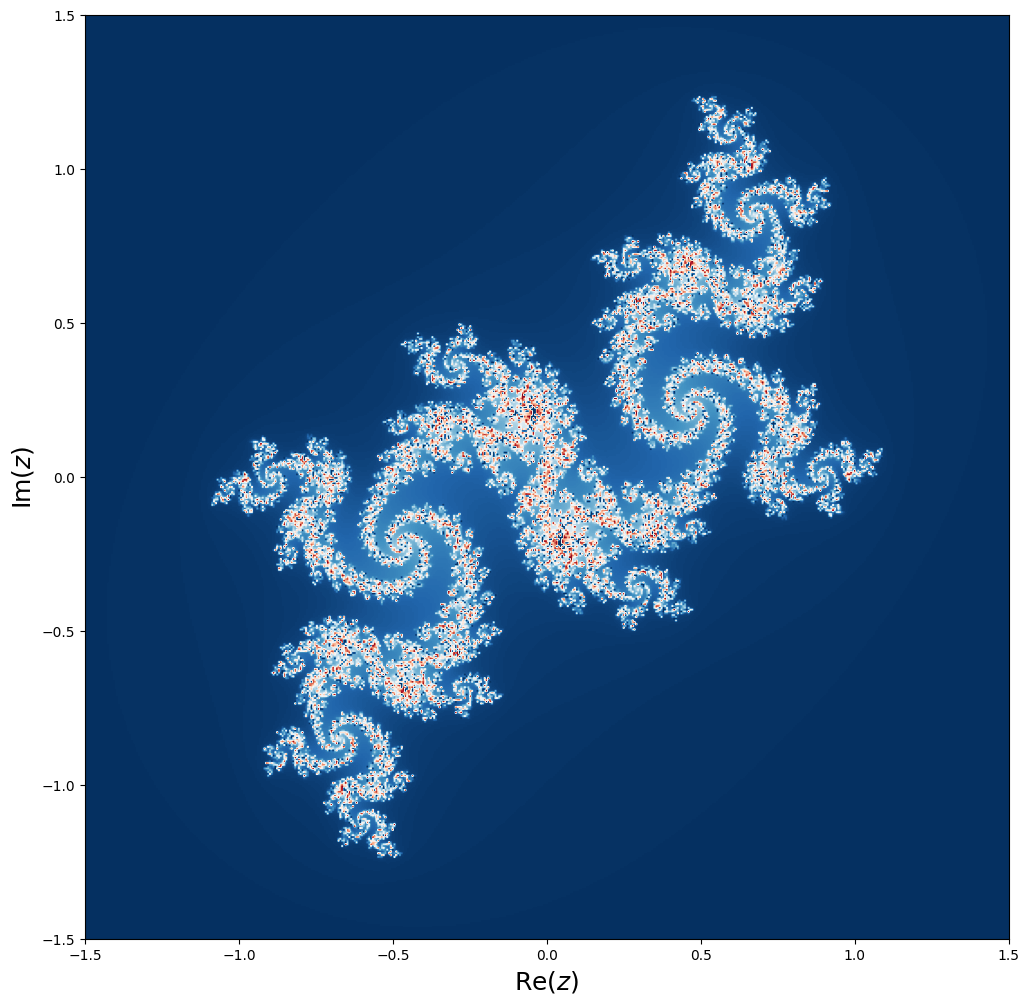

In [30]:
# Plot the Julia fractal result
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(j, cmap=plt.cm.RdBu_r, extent=[-1.5, 1.5, -1.5, 1.5])
ax.set_xlabel("$\\mathrm{Re}(z)$", fontsize=18)
ax.set_ylabel("$\\mathrm{Im}(z)$", fontsize=18)

This speed-up is quite remarkable. It is also interesting to note that a well-optimized NumPy implementation does not outperform the loop-heavy Numba version.  

This demonstrates the power of JIT compilation in handling complex, loop-based algorithms efficiently, where traditional array-based operations are not always faster.

In [31]:
# NumPy based Julia set evaluation
def julia_fractal_np(z_re, z_im, j):
    # Create a meshgrid of complex numbers from the real and imaginary components
    Z_re, Z_im = np.meshgrid(z_re, z_im)
    Z = Z_re + 1j * Z_im
    
    # Define the constant for the Julia set formula
    C = -0.05 + 0.68j
    
    # Initialize a mask to track points that haven't diverged yet
    mask = np.ones(Z.shape, dtype=bool)

    # Iterate up to 256 times to check for divergence
    for t in range(256):
        Z[mask] = Z[mask] ** 2 + C  # Update Z only for points that haven't diverged
        mask = np.abs(Z) <= 2.0  # Update the mask to track non-diverged points
        j[mask] = t  # Store the number of iterations before divergence

In [32]:
# Re-initialize the grid
j = np.zeros((N, N), np.int64)

In [33]:
%%timeit -n 3 -r 3

# Measure the NumPy-based implementation
julia_fractal_np(z_real, z_imag, j)

230 ms ± 4.58 ms per loop (mean ± std. dev. of 3 runs, 3 loops each)


This takes roughly **10X** of the Numba version. So yes, sometimes Numba can do better than Numpy. 
The other advantage is that the customized Numba function is lengthy but fully transparent: no use of masks, no calls to numpy functions... Just simple arithmetics, like c-style code.

### Lazy vs. Eager Compilation

The standard usage of the `@jit` or `@njit` decorator results in *lazy* compilation.

*Lazy* compilation means that the function is compiled only when it is first called. At that point, Numba infers the argument types based on the actual inputs and generates optimized code accordingly.

To perform *eager* compilation, we must explicitly provide Numba with the function signature in advance, specifying the expected types.

Returning to the `simple_sum` function, if we expect it to operate on a specific data type, we can inform the compiler ahead of time to enable type-specific compilation.

For example, if we want the function to handle single-precision floating-point numbers, we can specify this using `float32` or its shorthand `f4`.

Type name(s) |           Shorthand|        Comments|
---|---|---|
`boolean`                 |`b1`              |represented as a byte|
`uint8`, `byte`             |`u1`              |8-bit unsigned byte|
`uint16`                  |`u2`              |16-bit unsigned integer|
`uint32`                  |`u4`              |32-bit unsigned integer|
`uint64`                  |`u8`              |64-bit unsigned integer|
`int8`, `char`              |`i1`              |8-bit signed byte|
`int16`                   |`i2`              |16-bit signed integer|
`int32`                   |`i4`              |32-bit signed integer|
`int64`                   |`i8`              |64-bit signed integer|
`float32`                 |`f4`              |single-precision floating-point number|
`float64`, `double`         |`f8`              |double-precision floating-point number|
`complex64`               |`c8`              |single-precision complex number|
`complex128`              |`c16`              |double-precision complex number|


When declaring a function for eager JIT compilation, both the type and the structure of the input and output data must be specified:

- `type` represents a scalar value.  
- `type[:]` represents a vector (1D array).  

For example, the signature `int32(int32[:])` denotes a function that takes a one-dimensional array of 32-bit integers as input and returns a single 32-bit integer as output.

In [34]:
from numba import f4

# Function returning a float32 and taking an array of float32 as input
# Equivalent to using: @njit("float32(float32[:])")
@njit("f4(f4[:])")
def simple_sum_float32(data):
    s = 0  # Initialize sum
    for d in data:
        s += d  # Accumulate sum
    return s  # Return the result as a float32

In [35]:
# Inspect the types inferred and used by Numba for the eager-compiled function
simple_sum_float32.inspect_types()

simple_sum_float32 (Array(float32, 1, 'A', False, aligned=True),)
--------------------------------------------------------------------------------
# File: /var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_3684/3448625038.py
# --- LINE 5 --- 
# label 0
#   data = arg(0, name=data)  :: array(float32, 1d, A)

@njit("f4(f4[:])")

# --- LINE 6 --- 

def simple_sum_float32(data):

    # --- LINE 7 --- 
    #   s = const(int, 0)  :: Literal[int](0)
    #   s.2 = s  :: float64
    #   del s

    s = 0  # Initialize sum

    # --- LINE 8 --- 
    #   $10get_iter.2 = getiter(value=data)  :: iter(array(float32, 1d, A))
    #   del data
    #   $phi12.0 = $10get_iter.2  :: iter(array(float32, 1d, A))
    #   del $10get_iter.2
    #   jump 12
    # label 12
    #   $12for_iter.1 = iternext(value=$phi12.0)  :: pair<float32, bool>
    #   $12for_iter.2 = pair_first(value=$12for_iter.1)  :: float32
    #   $12for_iter.3 = pair_second(value=$12for_iter.1)  :: bool
    #   del $12for_iter.1
   

In [ ]:
# Generate an array of random floats scaled by 10 and converted to float32
input_data_f32 = 10.0 * np.random.random(100_000).astype('float32')

# Check the data type of the array elements
input_data_f32.dtype

In [ ]:
%%timeit -n 20 -r 5

# Measure the JIT-compiled function
simple_sum_float32(input_data_f32)

### Other Interesting Compilation Options and Usages

In addition to the main Numba compilation modes, several other useful options are available:

- **`nopython`**:  
  This option forces Numba to compile the function entirely to machine code, without relying on the Python `C` API. This typically yields the highest performance, but it requires that the types of all inputs and outputs can be inferred at compile time.  
  If Numba cannot infer these types (for example, when using unsupported Python objects), `@jit` will fall back to the so-called *object mode*, resulting in significantly slower execution.  
  Note that `@njit` is simply an alias for `@jit(nopython=True)`.

- **`cache`**:  
  This option instructs Numba to store compiled functions in a **file-based cache**.  
  When the same function is used again, Numba retrieves the precompiled version from the cache instead of recompiling it.  
  This is particularly useful in larger projects or multi-file workflows, as it avoids redundant compilation.

- **`parallel`**:  
  This option enables Numba to generate code that executes in parallel across multiple CPU cores (without the Global Interpreter Lock).  
  It supports *explicit parallel loop declarations*, allowing embarrassingly parallel workloads to be distributed across loop iterations.  
  You can activate this by using `numba.prange` instead of `range` in your loops.  

  However, *parallel execution does not guarantee a speedup*. Thread scheduling introduces overhead, which may outweigh the benefits when processing small datasets or short loops.



**Usage of cache:** it is useful when the same function is used across multiple scripts (e.g. multiple jupyter notebooks). This typically happens for large projects. E.g. you do something on this notebook, then you create a new notebook and you happen to need the very same function... With cache, you instruct numba to first look if the function already exists, and fetch its compiled version from the cache, if it exists. If numba doesn't find anything, it will compile it from scratch.

### Example - Gravitational Interaction

Given $N = 1000$ masses scattered in 3D space, we will compute the gravitational force exerted on each mass.

In this example, we will define a function to calculate the gravitational force on each mass based on its interactions with all other masses in the 3D space.

In [ ]:
from numba import prange # remember to import prange whenever you want to parallelize a loop!
# do NOT use np.arange()/ range()

# Gravitational constant in SI units
G = 6.67430e-11 

# Force Numba to parallelize:
# remember to use `prange` for the parallel loop
@njit(parallel=True)
def compute_gravitational_forces(masses, positions):
    # Number of particles
    n = masses.shape[0]
    
    # Initialize forces in 3D space (x, y, z)
    forces = np.zeros((n, 3))  

    # Loop over each pair of particles
    for i in prange(n):
        for j in prange(n):
            if i != j:  # Avoid self-interaction)
                r_vec = positions[j] - positions[i]  # Vector from i to j
                r_mag = np.sqrt(np.sum(r_vec ** 2))  # Magnitude of the distance vector
                
                # Magnitude of the gravitational force
                force_mag = G * masses[i] * masses[j] / r_mag ** 2
                
                # Update the force vector for particle i in the direction of j
                forces[i] += force_mag * r_vec / r_mag  

    return forces

In [37]:
# Number of particles
n_particles = 1_000

# Generate random masses between 1e16 and 1e32 (SI units)
masses = np.random.uniform(1e16, 1e32, n_particles)

# Generate random positions in 3D space between -1e11 and 1e11 (SI units)
positions = np.random.uniform(-1e11, 1e11, (n_particles, 3))

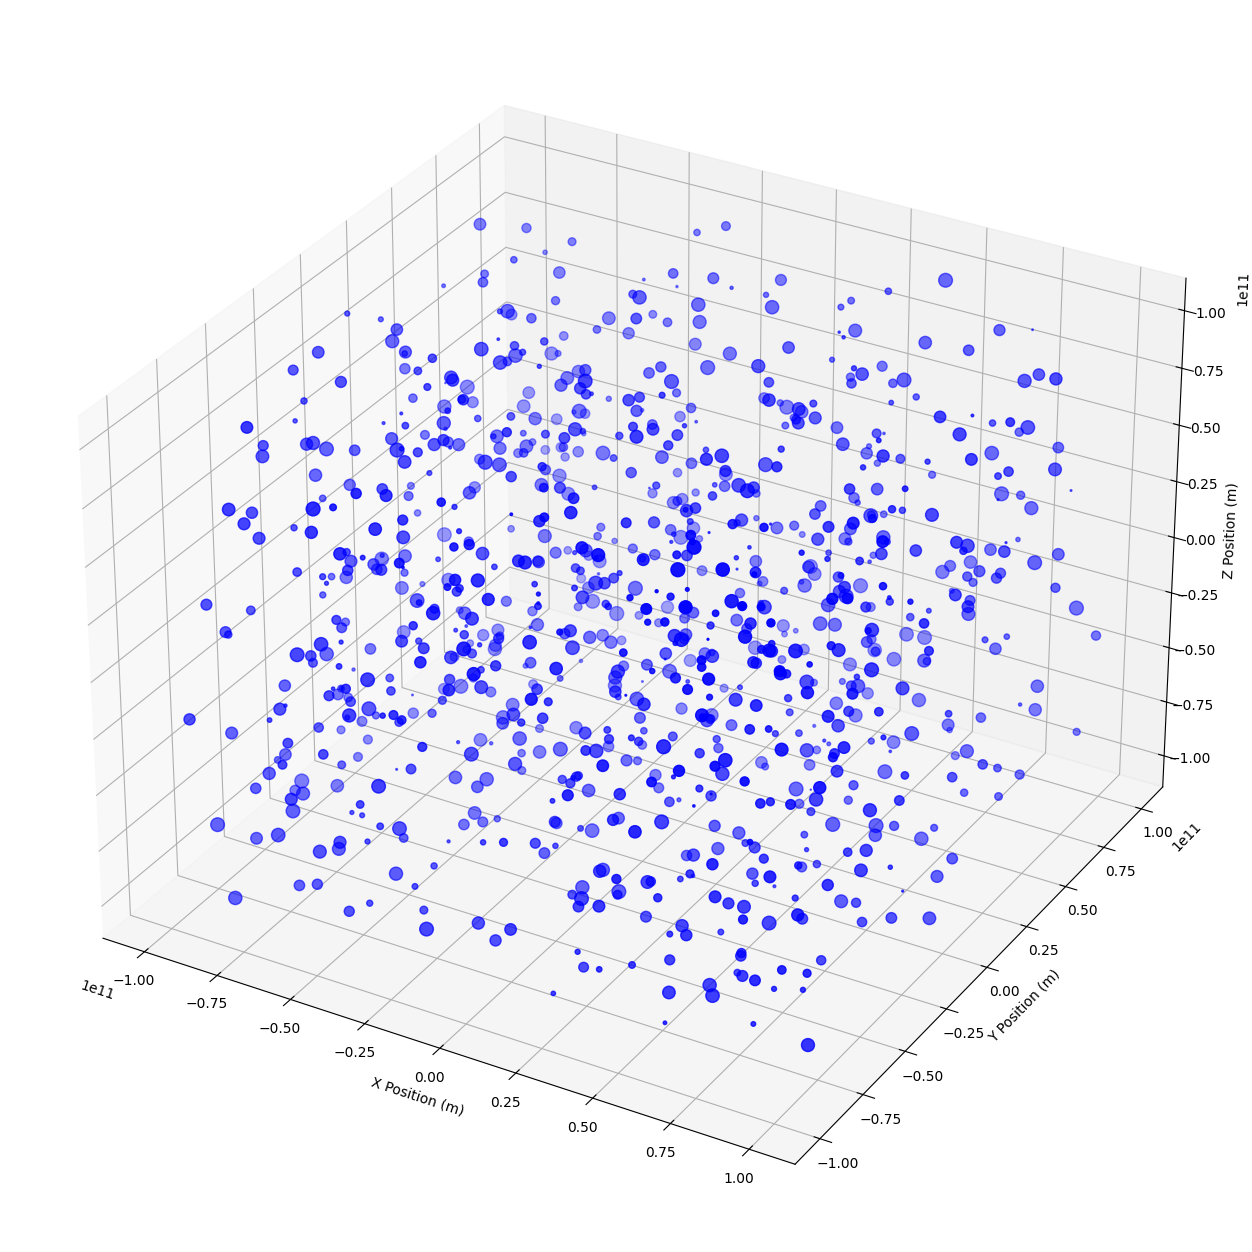

In [38]:
# Plot the particles in 3D space
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')

# Plot particles with size proportional to their masses
ax.scatter(
    positions[:, 0],
    positions[:, 1],
    positions[:, 2],
    color='blue',
    s=100 * masses / np.max(masses),  # Scale marker size by relative mass
)

# Label the axes
ax.set_xlabel("X Position (m)")
ax.set_ylabel("Y Position (m)")
ax.set_zlabel("Z Position (m)")

plt.show()

In [41]:
%%time

# Measure the JIT-compiled (eager) function
forces = compute_gravitational_forces(masses, positions)

CPU times: user 312 ms, sys: 4.28 ms, total: 317 ms
Wall time: 52.4 ms


Compiling the function  this time took the longest portion of the total runtime.  
The parallel execution of `compute_gravitational_forces` itself  was comparatively short.

*Compare timing for first-ever call and subsequent call: first around 1.3s, second around 0.3s.*

We could have opted for *eager* compilation by explicitly specifying the data types in advance.  
Let's now inspect the `shape` of the two input arrays and the types inferred by Numba.

In [42]:
# Check the shape of the masses and positions arrays
print(f"{masses.shape = }")
print(f"{positions.shape = }")

masses.shape = (1000,)
positions.shape = (1000, 3)


In [43]:
# Inspect the types inferred and used by Numba for the compute_gravitational_forces function
compute_gravitational_forces.inspect_types()

compute_gravitational_forces (Array(float64, 1, 'C', False, aligned=True), Array(float64, 2, 'C', False, aligned=True))
--------------------------------------------------------------------------------
# File: /var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_3684/2250336583.py
# --- LINE 8 --- 
# label 0
#   masses = arg(0, name=masses)  :: array(float64, 1d, C)
#   masses_shape.0 = getattr(value=masses, attr=shape)  :: UniTuple(int64 x 1)
#   masses_size0.1 = static_getitem(value=masses_shape.0, index=0, index_var=None, fn=<built-in function getitem>)  :: int64
#   del masses_shape.0
#   positions = arg(1, name=positions)  :: array(float64, 2d, C)

@njit(parallel=True)

# --- LINE 9 --- 

def compute_gravitational_forces(masses, positions):

    # --- LINE 10 --- 

    # Number of particles

    # --- LINE 11 --- 
    #   $6load_attr.1 = getattr(value=masses, attr=shape)  :: UniTuple(int64 x 1)
    #   $const26.2.1 = const(int, 0)  :: Literal[int](0)
    #   n = static_getite

In an eager implementation, we should have specified the shapes of the two input arrays:  
a 1D array for the masses (one scalar value per element) and **!!CAREFUL!!** a **2D** array for the positions (one 3D vector — *x, y, z* — per element).  

The same applies to the output, which, following the same logic, is a 2D array of forces (one 3D vector — *Fx, Fy, Fz* — per element).

```python
@njit("f8[:, :](f8[:], f8[:, :])", parallel=True)
```

In [ ]:
%%time

# If you have time to spare, measure the execution time of the non-jitted function
# forces = compute_gravitational_forces.py_func(masses, positions)

/var/folders/vk/kftm8379123bsmwrdp8l0xr00000gn/T/ipykernel_3684/1207480884.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('hot')


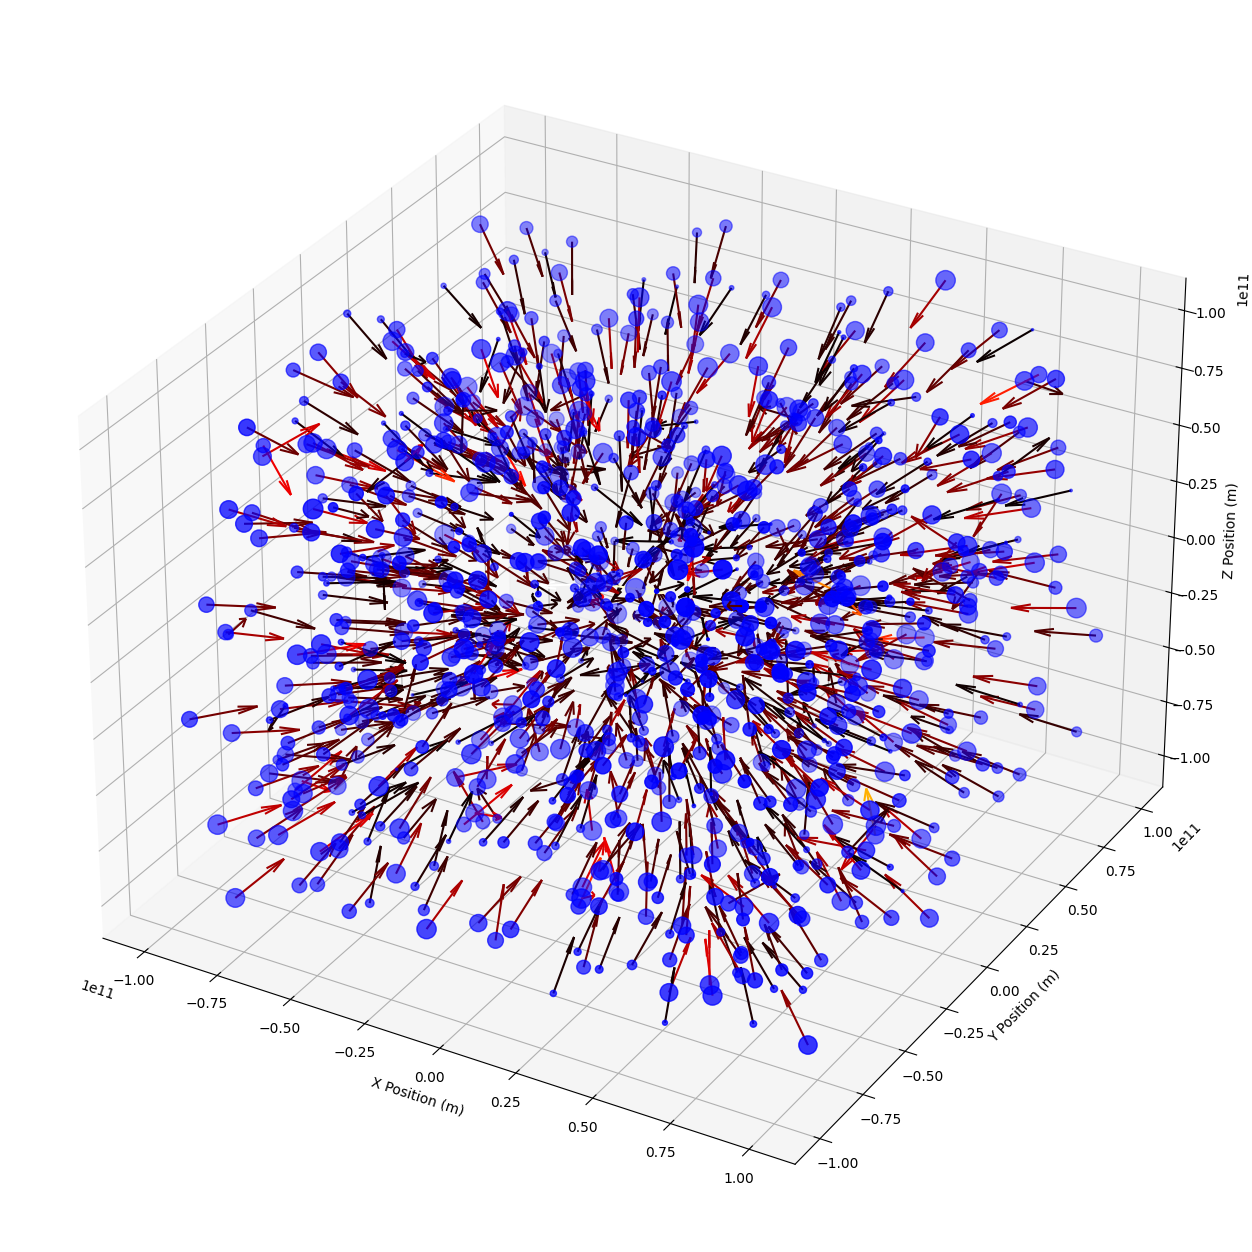

In [44]:
from matplotlib import cm

# Plotting the particles and their corresponding gravitational force vectors
fig = plt.figure(figsize=(16, 16))
ax = fig.add_subplot(111, projection='3d')

# Plot particles with size proportional to their masses
ax.scatter(positions[:, 0], positions[:, 1], positions[:, 2], 
           color='blue', s=200 * masses / max(masses))

# Compute force norms for color mapping
force_norms = np.linalg.norm(forces, axis=1)
normed_forces = (force_norms - force_norms.min()) / (force_norms.max() - force_norms.min())
cmap = cm.get_cmap('hot')

# Plot force vectors for each particle
for i in range(n_particles):
    ax.quiver(
        positions[i, 0], positions[i, 1], positions[i, 2], 
        forces[i, 0], forces[i, 1], forces[i, 2], 
        color=cmap(normed_forces[i]),  # Color based on the normalized force magnitude
        length=2e10,                   # Scale length of vectors for better visualization
        normalize=True                 # Normalize vectors for consistent representation
    )

# Set labels for the axes
ax.set_xlabel('X Position (m)')
ax.set_ylabel('Y Position (m)')
ax.set_zlabel('Z Position (m)')

# Show the plot
plt.show()

## @vectorize

### The Basics

In NumPy, *universal functions* or `ufunc`s are functions that operate on `ndarray`s in an element-wise fashion.  
Examples include the addition of two arrays or the multiplication of an array by a scalar.

Internally, NumPy implements these `ufunc`s in `C`, enabling efficient element-wise operations that can leverage vectorized computation.

Writing a custom `ufunc` in NumPy is typically complex, as it requires low-level understanding of NumPy’s `C` API.  
Numba simplifies this process by allowing you to create “vectorized” versions of Python functions that operate on scalar elements of a NumPy array with performance comparable to native `ufunc`s.

By applying the `@vectorize` decorator, Numba compiles a pure Python function into a `ufunc` that can efficiently operate over NumPy arrays.  
This approach is especially valuable for defining element-wise functions that cannot be expressed as simple combinations of existing NumPy operations.

The same considerations regarding *lazy* and *eager* compilation apply here as well.

Let's start by vectorizing a simple `simple_add` function using Numba's `@vectorize` decorator.  
We will use *eager compilation* to support both integer (32-bit and 64-bit) and floating-point (32-bit and 64-bit) data types.

The following implementation demonstrates how to define a function that adds two numbers and can be applied element-wise to NumPy arrays *of any shape*.

In [49]:
from numba import vectorize, int32, int64, float32, float64

# Vectorize the addition of two values
# Specialize this function to operate on integers (32-bit and 64-bit)
# or floating-point numbers (single and double precision)
@vectorize([
    'int32(int32, int32)',
    'int64(int64, int64)',
    'float32(float32, float32)',
    'float64(float64, float64)'
])
def simple_add(x, y):
    return x + y

In [50]:
# Generate two random arrays of floats
a = 10 * np.random.random(100_000)
b = 20 * np.random.random(100_000)

In [51]:
# Use the vectorized simple_add function to perform element-wise addition of arrays a and b
c = simple_add(a, b)

# Display the result
c

array([ 5.14588906, 10.5382671 , 10.0389921 , ..., 19.84854683,
        6.35687454,  4.42897405])

> Ordering of the type signatures **matters**. Numba will attempt to match the input types in the order they are provided. Therefore, more specific types should be listed before more general types to ensure correct type resolution during function calls.



In [45]:
# Define a vectorized function for addition with wrong type signatures ordering
@vectorize([
    'float64(float64, float64)',
    'float32(float32, float32)',
    'int64(int64, int64)',
    'int32(int32, int32)'
])
def wts_simple_add(x, y):
    return x + y

In [52]:
# convert previous arrays to a more specific dtype
a_f32 = a.astype('float32')
b_f32 = b.astype('float32')

**Take home message** If you know that 99% of the times you are going to use the function with `float32`, you should put `float32` as the first type on the list.  Indeed, look at the timings:

In [53]:
# Check the dtype chosen during the function call
print("Output dtypes:")
print("  Correct ordering:\t", simple_add(a_f32, b_f32).dtype)
print("  Wrong ordering:\t", wts_simple_add(a_f32, b_f32).dtype)

Output dtypes:
  Correct ordering:	 float32
  Wrong ordering:	 float64


In [55]:
%%timeit -n 30 -r 10

# check performance
simple_add(a, b)

55.5 µs ± 17.3 µs per loop (mean ± std. dev. of 10 runs, 30 loops each)


In [56]:
%%timeit -n 30 -r 10

simple_add(a_f32, b_f32)

32.3 µs ± 12.7 µs per loop (mean ± std. dev. of 10 runs, 30 loops each)


As expected, the `float32` implementation of `simple_add` outperforms the `float64` version.  
Check what happens with the wrong ordering of type signatures!

In [59]:
%%timeit -n 30 -r 10

wts_simple_add(a_f32, b_f32)

116 µs ± 59.8 µs per loop (mean ± std. dev. of 10 runs, 30 loops each)


#### Differences Between `@vectorize` and `@jit`

A common question is whether there is any difference between using `@vectorize` and writing a `@jit` function that operates on all elements of NumPy arrays.

There is an important distinction: functions compiled with `@vectorize` behave as true NumPy *universal functions* (`ufunc`s).  
As such, they automatically support additional features such as **reduction**, **accumulation**, and **broadcasting**.

Using the example above, we will now explore how these features extend the functionality of the `@vectorize` approach beyond what is typically achievable with a standard `@jit` function.

In [60]:
# Using broadcasting: adding a scalar to the array b
a_1 = 1  # Scalar value
c = simple_add(a_1, b)  # The scalar a_1 is broadcasted to each element of b
# AUTOMATIC BROADCASTING

# Display the result
c

array([ 4.77227689,  9.30738148,  2.56893692, ..., 19.4387725 ,
        3.64317761,  2.69088345])

In [61]:
# Using broadcasting with reshaped arrays
a_2 = a.reshape(100, 1_000)  # Reshape array a into a 2D array of shape (100, 1000)
b_2 = b.reshape(100, 1_000)  # Reshape array b into a 2D array of shape (100, 1000)

# Perform element-wise addition using the vectorized simple_add function
c = simple_add(a_2, b_2)

# Display the result
c

array([[ 5.14588906, 10.5382671 , 10.0389921 , ...,  6.43389005,
        18.39757105, 20.36756883],
       [ 7.73718986,  3.87917365,  8.76929114, ..., 21.80307381,
         9.37136079, 25.9407942 ],
       [15.15438533, 25.41510682, 16.02184424, ..., 24.49515333,
         8.91147044,  4.81834024],
       ...,
       [24.22036728,  7.12748607,  9.27380947, ..., 16.44761379,
        23.17568066, 20.74340892],
       [21.32108391, 12.12774722, 11.86666669, ..., 17.92981935,
        13.53520794, 17.32863871],
       [22.54731267, 11.50861562,  1.84411847, ..., 19.84854683,
         6.35687454,  4.42897405]])

In [62]:
# Performing reduction using the simple_add function
# This sums all elements of array a along the specified axis (0 in this case)
result_reduction = simple_add.reduce(a, axis=0)

# Display the result of the reduction
result_reduction

498485.38805283146

The `@vectorize` decorator in Numba supports multiple *targets* for executing a vectorized function:

- **`cpu`**:  
  Executes the vectorized function in a single-threaded manner on the CPU.

- **`parallel`**:  
  Executes the vectorized function in a multi-threaded manner across all available CPU cores (without the Global Interpreter Lock, or GIL).  
  This mode introduces a small overhead from thread scheduling, which can affect performance on small datasets. However, for large datasets, the overhead becomes negligible, making parallel execution highly effective.

- **`cuda`**:  
  Compiles the vectorized function as a GPU kernel for execution on CUDA-enabled devices.  
  This allows for substantial performance gains in workloads that are well-suited to GPU parallelization.

### Example - Invert Image

Given an RGB image, we aim to invert its colors using Numba’s `@vectorize` decorator.  

The goal is to define a function that takes an RGB image as input and returns a new image with inverted colors.  
This is achieved by subtracting each color channel’s intensity value from the maximum possible value, which is typically 255 for 8-bit images.

In [ ]:
# Define a vectorized function to invert the colors of an image
@vectorize(['uint8(uint8)'], target='parallel')
def invert_color(pixel):
    # Invert the color by subtracting from 255
    return 255 - pixel

In [ ]:
# Load a sample image using Matplotlib
image = plt.imread("sample_image.png")  # Read the image file

# Display the shape of the image
image.shape

In [ ]:
# Check the data type of the image array
image.dtype  # Displays the data type of the image

In [ ]:
# Convert the image to uint8 format (values between 0 and 255)
if image.dtype != np.uint8:
    # Scale pixel values and convert to uint8 if necessary
    image = (image * 255).astype(np.uint8)

In [ ]:
%%time

# Apply the vectorized function to invert the colors of the image
inverted_image = invert_color(image)  # Executes the color inversion in parallel

In [ ]:
# Plot the original and inverted images side by side
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Display the original image
ax[0].imshow(image)
ax[0].set_title("Original Image")
ax[0].axis("off")

# Display the inverted image
ax[1].imshow(inverted_image)
ax[1].set_title("Inverted Image")
ax[1].axis("off")

plt.show()

### Extending to `@guvectorize`

The `@vectorize` decorator enables the definition and compilation of element-wise functions for efficient execution.  
To work with NumPy arrays more flexibly, Numba provides the `@guvectorize` decorator, which allows you to write *generalized* universal functions.  
These functions can operate on an arbitrary number of elements from the input arrays and can return outputs with dimensions that differ from those of the inputs.

A key distinction between `@vectorize` and `@guvectorize` is that `@guvectorize` functions do **not** return their result values directly.  
Instead, they behave like "void" functions: **they receive the output arrays as arguments and populate them in place**.  
This behavior is **conceptually similar to how CUDA kernels operate**.

This design choice arises because the output arrays are allocated by NumPy’s dispatch mechanism, which then invokes the Numba-compiled function to perform the computation.

A simple example that illustrates the logic behind `@guvectorize` is the addition of a scalar value to all elements of an array.

In [ ]:
# Define a guvectorized function to add a scalar to each element of an input array
@guvectorize([(int64[:], int64, int64[:])], "(n),()->(n)", target="parallel")
def gu_vector_add(x, y, res):
    # Add the scalar y to each element of array x
    for i in range(x.shape[0]):
        res[i] = x[i] + y

    # Do not return res; the output array is filled in place
    pass

The declaration of input and output layouts in `@guvectorize` is typically expressed in symbolic form, such as `(n),()->(n)`.

- `()` represents a scalar (in this case, of type `int64`)  
- `(n)`, `(m)`, etc. represent one-dimensional arrays (e.g., `int64[:]`)  
- `(n,n)`, `(n,m)`, etc. represent two-dimensional arrays (e.g., `int64[:, :]`)  
- `...` can be used to denote higher-dimensional arrays or broadcasted dimensions  

In the previous example, this definition instructs NumPy that the function takes:
1. a one-dimensional array of *n* elements `(n)`,  
2. a scalar `()`, and  
3. returns a one-dimensional array with the **same** number of elements `(n)`.

As with other Numba decorators, you can provide a list of concrete type signatures to explicitly specify which input and output types the function should be compiled for.

In [ ]:
# Define a scalar value
sca = 10

# Create a random integer array with values between 0 and 100, of size 100,000
arr = np.random.randint(0, 100, size=100_000)

In [ ]:
%%time

# Apply the guvectorized function to add the scalar to each element of the array
result = gu_vector_add(arr, sca)

### Example - 1D Denoising

Consider a one-dimensional signal composed of a single frequency component with added Gaussian noise.  

We will apply a **moving average filter** to denoise the signal.  
This filter smooths out the noise by replacing each point in the signal with the average of its neighboring values within a specified window size.

In [ ]:
# Generate a realistic noisy signal (sine wave with added noise)
np.random.seed(123)  # For reproducibility
t = np.linspace(0, 4 * np.pi, 500)  # Time values
signal = np.sin(t)  # Base sine wave

# Visualize the original signal
plt.figure(figsize=(12, 3))
plt.plot(t, signal, color="green", label="Original Signal")

plt.title("Original Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Add Gaussian noise to the signal
noise = np.random.normal(scale=0.5, size=t.shape)
noisy_signal = signal + noise

# Visualize the noisy signal
plt.figure(figsize=(12, 3))
plt.plot(t, signal, color="green", label="Original Signal")
plt.plot(t, noisy_signal, color="grey", label="Noisy Signal")

plt.title("Noisy Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Define a simple moving average kernel
kernel_size = 20
kernel = np.ones(kernel_size) / kernel_size  # Average kernel -> [1/20, 1/20, 1/20, ...]

# Visualize the noisy signal and an example of the kernel
plt.figure(figsize=(12, 3))
plt.plot(t, signal, color="green", label="Original Signal")
plt.plot(t, noisy_signal, color="grey", label="Noisy Signal")
plt.plot(t[:kernel_size], kernel, color="red", label="Kernel")

plt.title("Kernel")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Define the convolution function using guvectorize
@guvectorize([(float64[:], float64[:], float64[:])], "(n),(k)->(n)", target="parallel")
def convolve_1d(signal, kernel, result):
    n = signal.shape[0]   # Length of the input signal
    k = kernel.shape[0]   # Length of the convolution kernel
    half_k = k // 2       # Half the kernel size for centering

    for i in range(n):
        tmp = 0.0  # Temporary variable to store the convolution sum
        for j in range(k):
            # Check bounds to avoid accessing invalid indices
            if 0 <= i - half_k + j < n:
                tmp += signal[i - half_k + j] * kernel[j]  # Accumulate weighted sum
        result[i] = tmp  # Store the convolution result

In [ ]:
# Create an output array to hold the convolution result
smoothed_signal = np.empty_like(noisy_signal)

# Perform the convolution
convolve_1d(noisy_signal, kernel, smoothed_signal)

# Visualize the original, noisy, and smoothed signals
plt.figure(figsize=(12, 3))
plt.plot(t, signal, color="green", label="Original Signal")
plt.plot(t, noisy_signal, color="grey", label="Noisy Signal")
plt.plot(t, smoothed_signal, color="blue", label="Smoothed Signal")

plt.title("Smoothed Signal with Moving Average")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()